# init

In [1]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
!pip install skorch
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping
import pickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 6.2 MB/s eta 0:00:00


In [2]:
db = pd.read_csv("database2.csv")
db = pd.concat([pd.read_csv("database25.csv"), db]).drop("Unnamed: 0", axis = 1)

In [3]:
db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db["eFG_team1"] - db["opp_eFG_team2"]
db_used["net_TOV_pct"] = db["TOV_pct_team1"] - db["opp_TOV_pct_team2"]
# db_used["net_ORB_pct"] = db["ORB_pct_team1"] - db["opp_ORB_pct_team2"]
# db_used["net_FT_FGA"] = db["FT_FGA_team1"] - db["opp_FT_FGA_team2"]


# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db["eFG_team2"] - db["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db["TOV_pct_team2"] - db["opp_TOV_pct_team1"]
# mirrored["net_ORB_pct"] = db["ORB_pct_team2"] - db["opp_ORB_pct_team1"]
# mirrored["net_FT_FGA"] = db["FT_FGA_team2"] - db["opp_FT_FGA_team1"]
mirrored

X = np.vstack([np.array(db_used), np.array(mirrored)])

In [4]:
y = np.array(db["win"]).reshape(-1,1)
y = np.vstack([y, 1 - y])

# y = np.vstack([y.reshape(-1,1), y.reshape(-1,1)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state = 0)

scaler = StandardScaler()
scaler.fit(X_train)
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

X_train = torch.as_tensor(X_train, dtype = torch.float32)
X_test = torch.as_tensor(X_test, dtype = torch.float32)
# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

# model training

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from time import time
from google.colab import files

In [ ]:
variance = {}
for i in range(X_train.shape[1] + 1):
    pca = Pipeline([("scaler", scaler), ("pca", PCA(random_state=0, n_components=i))])
    pca.fit(X_train)
    variance[i] = np.sum(pca.named_steps["pca"].explained_variance_ratio_)

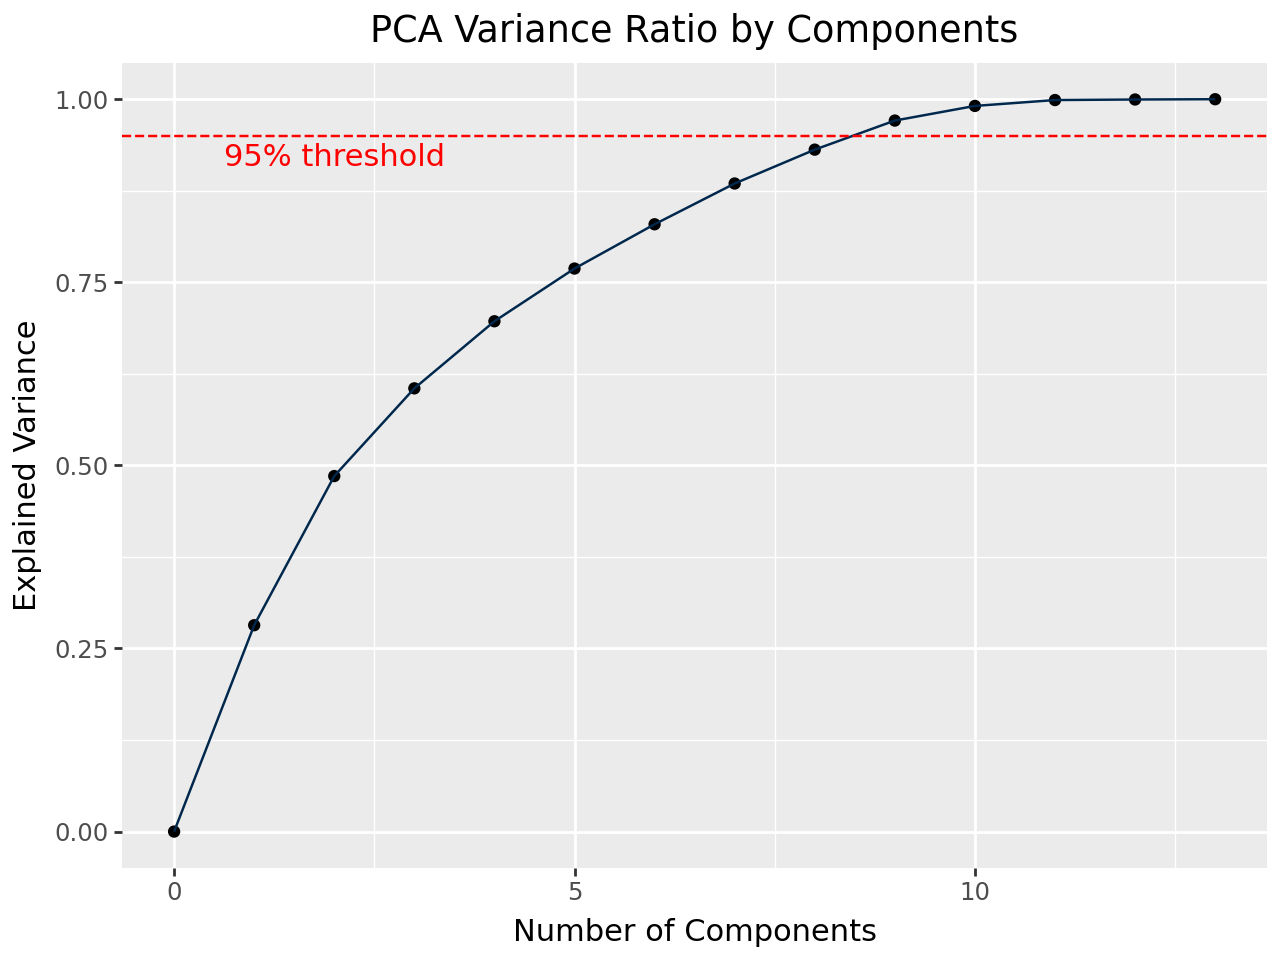

In [ ]:
from plotnine import *
comps = list(variance.keys())
vars = list(variance.values())
comp = next(i for i in iter(variance) if variance[i] >= .95)
ggplot() + geom_point(aes(x = comps, y = vars)) + geom_line(aes(x = comps, y = vars),
color = "#00274C") + xlab("Number of Components") + ylab("Explained Variance"
) + labs(title = "PCA Variance Ratio by Components") + geom_hline(
    yintercept = .95, linetype = "dashed", color = "red"
) + annotate("text", x = 2, y = .92, label = "95% threshold", color = "red")

In [ ]:
pca = Pipeline([("scaler", scaler), ("pca", PCA(random_state=0, n_components=9))])
pca.fit(X_train)
np.sum(pca.named_steps["pca"].explained_variance_ratio_)

np.float64(0.9708477572708291)

In [ ]:
with open('scaler_plus_PCA_fitted_13.pkl', 'wb') as f:
    pickle.dump(pca, f)

In [ ]:
with open('scaler_plus_PCA_fitted_13.pkl', 'rb') as f:
    pca = pickle.load(f)

In [ ]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
from scipy.stats import loguniform, uniform

In [ ]:
nested_CV = {
    "rf" : {"model" : RandomForestClassifier(random_state = 0),
                      "params" : {
    "n_estimators": range(25,225,25),
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : [None] + list(range(1,30)),
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : range(1,11),
    "max_features" : ["sqrt","log2",.2,.5]
}},
    "ada" : {"model" : AdaBoostClassifier(random_state = 0),
             "params" : {
    "n_estimators" : range(10,160,10),
    "learning_rate" : list(i/10 for i in range(1,11))
}},
    "xgb" : {"model" : XGBClassifier(),
             "params" : {
    "booster" : ["gbtree", "dart"],
    # "eta" : [.0001,.001,.005, .01, .025, .05, .1, .25, .5, 1],
    # "gamma" : [0, .5, 1, 2, 5, 10],
    "eta": loguniform(1e-4, 1.0),
    "gamma": uniform(0, 10),
    "max_depth" : [1, 2, 4, 6, 12, 15],
    "min_child_weight" : [1, 2, 4, 5]
}},
    "svc" : {"model" : SVC(random_state=0, probability=True),
             "params" : {
    # "C" : list(i/10 for i in range(1,51)),
    "C": loguniform(1e-2, 1e2),
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : range(1,6),
    "gamma" : ["scale", "auto", 0.005, 0.5]
}},
    "bag" : {"model" : BaggingClassifier(random_state=0),
             "params" : {
    "n_estimators" : range(1,251),
    "max_samples" : [ 0.2, 0.5, 0.75, 1],
    "max_features" : [0.2, 0.4, 0.5, 0.7, 0.9]
}},
    "gb" : {"model" : GradientBoostingClassifier(random_state=0),
            "params" : {
    "loss" : ["log_loss", "exponential"],
    "learning_rate" : [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1, 0.2, .5, 0.6, 1],
    "n_estimators" : range(10,1000,10),
    "criterion" : ["friedman_mse", "squared_error"],
    "min_samples_split" : [2, 4, 5, 8, 10],
    "max_depth" : [2, 3, 4, 5, 8, 10],
    "max_features": ["sqrt","log2", 0.1, 0.2, 0.4, 0.5, 0.8, 1]
}},
    "sgd" : {"model" : SGDClassifier(random_state=0),
             "params" : {
    "loss" : ["log_loss"],
    "penalty" : ["elasticnet"],
    "l1_ratio" : [0, 0.001, 0.005, .01, .05, .1, .25, .5, .7, .9, .95, 1],
    "learning_rate" : ["optimal", "adaptive"],
    "eta0" : [0.0001, .0005, .001, .005, .01, .025, .05, .1],
    "early_stopping" : [True, False]
}}
}

In [ ]:
start = time()
for model in ['nn', 'rf', 'ada', 'xgb', 'svc', 'bag', 'gb', 'log', 'sgd']:
    if model not in {"nn", "log"}:
        # pipe = Pipeline([("pca_scaler", pca), (model, nested_CV[model]["model"])])
        # curr_model = RandomizedSearchCV(pipe, nested_CV[model]["params"],
        #                                 n_jobs = -1, n_iter = 150)
        curr_model = RandomizedSearchCV(nested_CV[model]["model"],
                                        nested_CV[model]["params"],
                                         n_jobs = -1, n_iter = 75,
                                        scoring = "neg_log_loss")
        curr_model.fit(X_train_pca, y_train.ravel())
        best = curr_model.best_estimator_
        print(f"Model {model} done")
        y_pred = best.predict_proba(X_test_pca)[:,-1] + 1e-16
        print(f"Test Log Loss: {-np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))}")
        print(f"Time elpased: {round((time() - start)/60,2)} minutes")
        print(curr_model.best_params_)
        print()
        with open(f'{model}_9_pca.pkl', 'wb') as f:
            pickle.dump(best, f)
        files.download(f"{model}_9_pca.pkl")

Model rf done
Test Log Loss: 0.5533364348287265
Time elpased: 2.51 minutes
{'n_estimators': 125, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 0.5, 'max_depth': 26, 'criterion': 'log_loss'}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model ada done
Test Log Loss: 0.5633580262567495
Time elpased: 4.23 minutes
{'n_estimators': 30, 'learning_rate': 0.2}



<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model sgd done
Test Log Loss: 0.5343815590822185
Time elpased: 28.02 minutes
{'penalty': 'elasticnet', 'loss': 'log_loss', 'learning_rate': 'adaptive', 'l1_ratio': 0.5, 'eta0': 0.0005, 'early_stopping': False}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# log = Pipeline([("pca_scaler", pca), ("log", LogisticRegressionCV(random_state=0))])
log = LogisticRegressionCV(random_state=0)

log.set_params(Cs = 30, l1_ratios = [.01, .05, .1, .3, .5, .7, .9],
               cv = 10, scoring = "neg_log_loss", max_iter = 1000,
               penalty = "elasticnet", solver = "saga")
log.fit(X_train_pca, y_train.ravel())

LogisticRegressionCV(Cs=30, cv=10,
                     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9],
                     max_iter=1000, penalty='elasticnet', random_state=0,
                     scoring='neg_log_loss', solver='saga')

In [ ]:
print(f"Model log done")
y_pred = log.predict_proba(X_test_pca)[:,-1] + 1e-16
print(f"Test Log Loss: {-np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))}")
print()
with open(f'log_9_pca.pkl', 'wb') as f:
    pickle.dump(best, f)
files.download(f"log_9_pca.pkl")

Model log done
Test Log Loss: 0.5349065517110152



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
log.l1_ratio_, log.C_

(array([0.9]), array([0.10826367]))

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int , output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        # return self.sigmoid(x)
        return x

In [ ]:
from skorch import NeuralNetClassifier
from sklearn.model_selection import RandomizedSearchCV
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

X_pca = torch.tensor(pca.transform(X_train), dtype = torch.float32)

net = NeuralNetClassifier(
    module=Model,
    module__input_size=X_pca.shape[1],
    criterion=torch.nn.BCEWithLogitsLoss,
    optimizer=torch.optim.Adam,
    max_epochs=500,
    verbose=0, # Set to 0 to keep the output clean during search
    callbacks=[EarlyStopping(patience=20, monitor='valid_loss')], # Early Stopping
    train_split=ValidSplit(cv=5) # Required for EarlyStopping to have a validation set
)

params = {
    'lr': loguniform(1e-4, 1e-1),        # Learning Rate
    'module__n_layers': np.arange(1, 5),                  # Number of Layers
    'module__hidden_dim': [16, 32, 64, 128],          # Hidden Size
    'module__dropout': uniform(0, 0.5), # Random float between 0 and 0.5
    'optimizer__weight_decay': loguniform(1e-5, 1e-1), # Lambda (L2 Regularization)
}

rs = RandomizedSearchCV(net, params, n_iter=250, cv=5, scoring='neg_log_loss', n_jobs = -1)
rs.fit(X_pca, y_train)

RandomizedSearchCV(cv=5,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__input_size'}, batch_size=128, callbacks=[<skorch.callbacks.training.EarlyStopping object at 0x79fe931efa10>], compile=False, criterion=<class 'torch.nn.modules.loss.BCEWithLogitsLoss'>, dataset=<class 'skorch.dataset.Dataset'>, device='cpu', iterator_train=<class 'torch.utils.da...
                   param_distributions={'lr': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79fe9364ae40>,
                                        'module__dropout': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79fe80693a40>,
                                        'module__hidden_dim': [16, 32, 64, 128],
                                        'module__n_layers': array([1, 2, 3, 4]),
                                        'optimizer__weight_decay': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79fe806925a0>},
                   scoring='neg_log_loss')

In [ ]:
rs.best_estimator_

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Model(
    (layers): ModuleList(
      (0): Linear(in_features=9, out_features=64, bias=False)
      (1-2): 2 x Linear(in_features=64, out_features=64, bias=False)
    )
    (bn_layers): ModuleList(
      (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (dropout): Dropout(p=0.32688836283896966, inplace=False)
    (output_layer): Linear(in_features=64, out_features=1, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  ),
)

In [ ]:
rs.best_params_

{'lr': np.float64(0.00020941160222188228),
 'module__dropout': np.float64(0.32688836283896966),
 'module__hidden_dim': 64,
 'module__n_layers': np.int64(2),
 'optimizer__weight_decay': np.float64(0.007227994915692181)}

In [ ]:
nn = rs.best_estimator_
y_pred = nn.predict_proba(torch.tensor(X_test_pca, dtype = torch.float32))[:,-1,0] #[:,-1] + 1e-16
print(f"Test Log Loss: {-np.mean(y_test.numpy().ravel()*np.log(y_pred) + (1 - y_test.numpy().ravel())*np.log(1 - y_pred))}")
print()
with open(f'nn_9_pca.pkl', 'wb') as f:
    pickle.dump(best, f)
files.download(f"nn_9_pca.pkl")

Test Log Loss: 0.5495727062225342



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# voting

In [ ]:
with open('nn_9_pca.pkl', 'rb') as f:
    nn = pickle.load(f)

with open('rf_9_pca.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('ada_9_pca.pkl', 'rb') as f:
    ada = pickle.load(f)

with open('xgb_9_pca.pkl', 'rb') as f:
    xgb = pickle.load(f)

with open('scaler_plus_PCA_fitted_13.pkl', 'rb') as f:
    pca = pickle.load(f)

with open("sgd_9_pca.pkl", "rb") as f:
    sgd = pickle.load(f)

with open("svc_9_pca.pkl", "rb") as f:
    svc = pickle.load(f)

with open("bag_9_pca.pkl", "rb") as f:
    bag = pickle.load(f)

with open("gb_9_pca.pkl", "rb") as f:
    gb = pickle.load(f)

with open("log_9_pca.pkl", "rb") as f:
    log = pickle.load(f)

nn_probs = nn.predict_proba(torch.tensor(X_test_pca, dtype = torch.float32))[:,-1]
rf_probs = rf.predict_proba(X_test_pca)[:,-1]
ada_probs = ada.predict_proba(X_test_pca)[:,-1]
xgb_probs = xgb.predict_proba(X_test_pca)[:,-1]
svc_probs = svc.predict_proba(X_test_pca)[:,1]
bag_probs = bag.predict_proba(X_test_pca)[:,1]
gb_probs = gb.predict_proba(X_test_pca)[:,1]
log_probs = log.predict_proba(X_test_pca)[:,1]
sgd_probs = sgd.predict_proba(X_test_pca)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# Generate 500 random weight combinations that sum to 1
num_trials = 5000
weight_samples = np.random.dirichlet(np.ones(9), size=num_trials)

results = []

for weights in weight_samples:
    c1, c2, c3, c4, c5, c6, c7, c8, c9 = weights

    # Calculate ensemble prediction
    vote_pred = (c1 * nn_probs + c2 * rf_probs + c3 * ada_probs + c4 * xgb_probs +
                 c5 * svc_probs + c6 * bag_probs + c7 * gb_probs + c8 * log_probs +
                 c9 * sgd_probs)

    # Use sklearn to find best threshold (much faster than 0-1001 loop)
    fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
    j_scores = tpr_list - fpr_list
    best_tau = thresholds[np.argmax(j_scores)]

    # Calculate metrics at best_tau
    y_bin = (vote_pred >= best_tau).astype(int)
    acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
    loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
     (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

    results.append({
        'weights': weights,
        'tau': best_tau,
        "tpr" : tpr_list[np.argmax(j_scores)],
        "fpr" : fpr_list[np.argmax(j_scores)],
        'acc': acc,
        'auc': auc(fpr_list, tpr_list),
        "loss" : loss
    })

# Find the winner
best_run = min(results, key=lambda x: x['loss'])
print(f"Best Weights: {best_run['weights']}")
print(f"Max Accuracy: {best_run['acc']}")

Best Weights: [5.79404985e-01 7.17116085e-03 1.42491984e-03 6.67780891e-03
 2.78125198e-04 1.87070311e-02 2.82991530e-01 8.47422401e-02
 1.86021983e-02]
Max Accuracy: 0.7551020408163265


In [ ]:
best_run

{'weights': array([5.79404985e-01, 7.17116085e-03, 1.42491984e-03, 6.67780891e-03,
        2.78125198e-04, 1.87070311e-02, 2.82991530e-01, 8.47422401e-02,
        1.86021983e-02]),
 'tau': np.float64(0.575638562426314),
 'tpr': np.float64(0.6738197424892703),
 'fpr': np.float64(0.15384615384615385),
 'acc': np.float64(0.7551020408163265),
 'auc': np.float64(0.8109111918124794),
 'loss': np.float64(0.5340057383302771)}

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
        w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
        w[8] * sgd_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_test.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]

n = 9
initial_guess = np.ones(n)/n
bounds = [(0, 1)] * n # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [1.89727532e-01 0.00000000e+00 0.00000000e+00 2.83782246e-17
 1.72846353e-01 0.00000000e+00 2.57971050e-01 1.89727532e-01
 1.89727533e-01]


In [ ]:
np.round(best_weights, 3)

array([0.19 , 0.   , 0.   , 0.   , 0.173, 0.   , 0.258, 0.19 , 0.19 ])

In [ ]:
objective(best_weights)

0.5335615998972009

In [ ]:
results = []
from sklearn.metrics import roc_auc_score, roc_curve, auc
loss_fn = torch.nn.BCELoss()

# vote_pred = .2127*bag_probs + .4884*sgd_probs + .2987*log_probs
# vote_pred = sgd_probs
w = best_weights
vote_pred = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
        w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
        w[8] * sgd_probs)

fpr_list, tpr_list, thresholds = roc_curve(y_test, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_test.reshape(-1).detach().numpy()).mean()
loss = -np.mean(y_test.numpy().ravel()*np.log(vote_pred) +
  (1 - y_test.numpy().ravel())*np.log(1 - vote_pred) )

results.append({
    # 'weights': weights,
    'tau': best_tau,
    'acc': acc,
    "tpr" : tpr_list[np.argmax(j_scores)],
    "fpr" : fpr_list[np.argmax(j_scores)],
    'auc': auc(fpr_list, tpr_list),
    "loss" : loss
})

# Find the winner
# best_run = min(results, key=lambda x: x['loss'])
# print(f"Best Weights: {best_run['weights']}")
# print(f"Max Accuracy: {best_run['acc']}")
results

[{'tau': np.float64(0.5761559798295578),
  'acc': np.float64(0.7551020408163265),
  'tpr': np.float64(0.6781115879828327),
  'fpr': np.float64(0.15865384615384615),
  'auc': np.float64(0.8111587982832618),
  'loss': np.float64(0.5335615998972009)}]

In [ ]:
from sklearn.metrics import precision_score
precision_score(y_test.ravel(), y_bin)

0.8272251308900523

# bracket sim

In [ ]:
matchups = pd.read_csv("matchups26.csv").drop("Unnamed: 0", axis = 1)
teamstats26 = pd.read_csv("teamstats26.csv").drop("Unnamed: 0", axis = 1)
teamstats26 = teamstats26.loc[teamstats26['school_name'].isin(list(matchups["team1"]) + list(matchups["team2"]))]
db26 = pd.read_csv("database26.csv").drop("Unnamed: 0", axis = 1)

seeds = {(list(db26["team1"]) + list(db26["team2"]))[i] : (list(db26["team1_seed"]) + list(db26["team2_seed"]))[i] for i in range(64)}

In [ ]:
# db_used = db26.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fg", "3par"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_efg"] = db26["efg_team1"] - db26["opp_efg_team2"]
db_used["net_tov_pct"] = db26["tov_pct_team1"] - db26["opp_tov_pct_team2"]
# db_used["net_ORB_pct"] = db["ORB_pct_team1"] - db["opp_ORB_pct_team2"]
# db_used["net_FT_FGA"] = db["FT_FGA_team1"] - db["opp_FT_FGA_team2"]


# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_efg"] = db26["efg_team2"] - db26["opp_efg_team1"]
mirrored["net_tov_pct"] = db26["tov_pct_team2"] - db26["opp_tov_pct_team1"]
# mirrored["net_ORB_pct"] = db["ORB_pct_team2"] - db["opp_ORB_pct_team1"]
# mirrored["net_FT_FGA"] = db["FT_FGA_team2"] - db["opp_FT_FGA_team1"]
mirrored

X = np.vstack([np.array(db_used), np.array(mirrored)])

X_pca = pca.transform(X)

In [ ]:
nn_probs = nn.predict_proba(torch.tensor(X_pca, dtype = torch.float32))[:,-1]
rf_probs = rf.predict_proba(X_pca)[:,-1]
ada_probs = ada.predict_proba(X_pca)[:,-1]
xgb_probs = xgb.predict_proba(X_pca)[:,-1]
svc_probs = svc.predict_proba(X_pca)[:,1]
bag_probs = bag.predict_proba(X_pca)[:,1]
gb_probs = gb.predict_proba(X_pca)[:,1]
log_probs = log.predict_proba(X_pca)[:,1]
sgd_probs = sgd.predict_proba(X_pca)[:,1]

In [ ]:
# w = best_weights
w = [.2,0,.4,0,0, 0, .4, 0,0]
vote_pred = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
        w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
        w[8] * sgd_probs)
# vote_pred = gb_probs

In [ ]:
db_eval = pd.DataFrame(np.vstack([db26.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db26.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
db_eval1 = db_eval[:len(db_eval)//2].reset_index().copy()
db_eval2 = db_eval[-len(db_eval)//2:].reset_index().copy()
db_eval["avg_team1_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:len(db_eval)//2].copy().drop("team1_pred", axis = 1)
db_eval.to_csv("r64preds.csv", index = False)
db_eval

,team1,team2,team1_seed,team2_seed,avg_team1_pred
0,Duke,Siena,1,16,0.870495
1,Ohio State,TCU,8,9,0.580273
2,St. John's (NY),Northern Iowa,5,12,0.847394
3,Kansas,California Baptist,4,13,0.804085
4,Louisville,South Florida,6,11,0.432041
5,Michigan State,North Dakota State,3,14,0.688199
6,UCLA,UCF,7,10,0.805419
7,UConn,Furman,2,15,0.874075
8,Florida,Prairie View A&M,1,16,0.869464
9,Clemson,Iowa,8,9,0.618369


In [ ]:
class Bracket:

    def __init__(self, round_64: list[tuple[str,str]]):

        self.rounds: dict[int, list[tuple[str, str]]] = dict()
        self.rounds[64] = round_64
        for round in list(2**i for i in range(5,0,-1)):
            self.rounds[round] = list()

In [ ]:
def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    needed_cols: list[str] = ["school_name","srs","sos","ORtg","DRtg","pace","efg", "opp_efg",
                              "orb_pct","tov_pct", "opp_tov_pct", "ft_fga", "3par"]

    # scaler = StandardScaler()
    db_used = db26.loc[:,list(c for c in db26.columns if any(t in c for t in {"seed","srs","sos","ORtg","DRtg","pace","efg","orb_pct","tov_pct","ft_fga", "3par"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

    # adding net stats
    db_used["net_efg"] = db26["efg_team1"] - db26["opp_efg_team2"]
    db_used["net_tov_pct"] = db26["tov_pct_team1"] - db26["opp_tov_pct_team2"]

    mirrored = -db_used.iloc[:,:-2].copy()
    mirrored["net_efg"] = db26["efg_team2"] - db26["opp_efg_team1"]
    mirrored["net_tov_pct"] = db26["tov_pct_team2"] - db26["opp_tov_pct_team1"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    # X = scaler.transform(X)
    X_pca = pca.transform(X)
    db_next = db26.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        # gb_probs = gb.predict_proba(X_pca)[:,1]
        # ada_probs = ada.predict_proba(X_pca)[:,-1]
        # nn_probs = nn.predict_proba(torch.tensor(X_pca, dtype = torch.float32))[:,-1]

        # vote_pred = .05*nn_probs + .25*ada_probs + .7*gb_probs

        nn_probs = nn.predict_proba(torch.tensor(X_pca, dtype = torch.float32))[:,-1]
        rf_probs = rf.predict_proba(X_pca)[:,-1]
        ada_probs = ada.predict_proba(X_pca)[:,-1]
        xgb_probs = xgb.predict_proba(X_pca)[:,-1]
        svc_probs = svc.predict_proba(X_pca)[:,1]
        bag_probs = bag.predict_proba(X_pca)[:,1]
        gb_probs = gb.predict_proba(X_pca)[:,1]
        log_probs = log.predict_proba(X_pca)[:,1]
        sgd_probs = sgd.predict_proba(X_pca)[:,1]

        # w = best_weights
        w = [.2,0,.4,0,0, 0, .4, 0,0]
        vote_pred = (w[0] * nn_probs + w[1] * rf_probs + w[2] * ada_probs + w[3] * xgb_probs +
                w[4] * svc_probs + w[5] * bag_probs + w[6] * gb_probs + w[7] * log_probs +
                w[8] * sgd_probs)

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
            # list(zip(db25["team1"], db25["team2"]))
        # bracket.rounds[round//2] = list((db_eval["winner"].values[::2][i],
        #                                 db_eval["winner"].values[1::2][i]) for i in range(round//4))
        bracket.rounds[round//2] = list(db_eval["winner"].values)
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)
                # bracket.rounds[round].append((t1,t2))

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            # print('here')
            db_next = pd.merge(
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "school_name_team1"),
                pd.merge(db_next, teamstats26.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "school_name_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["school_name_team1", "school_name_team2"], axis = 1)

            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            # adding net stats
            db_used["net_efg"] = db_next["efg_team1"] - db_next["opp_efg_team2"]
            db_used["net_tov_pct"] = db_next["tov_pct_team1"] - db_next["opp_tov_pct_team2"]

            mirrored = -db_used.iloc[:,:-2].copy()
            mirrored["net_efg"] = db_next["efg_team2"] - db_next["opp_efg_team1"]
            mirrored["net_tov_pct"] = db_next["tov_pct_team2"] - db_next["opp_tov_pct_team1"]

            X = np.vstack([np.array(db_used), np.array(mirrored)])

            X_pca = pca.transform(X)

    for team in teamstats26["school_name"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            # bracket.rounds[2].append(team)
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
                bracket.rounds[1] = team
            # else:
            #     bracket.rounds[2].append(team)
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes, bracket

In [ ]:
bracket = Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)])
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 1
i: int = 0
start = time()

finishes, bracket = MC_MM(finishes, bracket)

brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time()
for id in range(1):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in bracket.rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(bracket.rounds[round][::2], bracket.rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]

In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats26["school_name"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 10000
i: int = 0
start = time()

brackets = list(Bracket(round_64 = [(db26["team1"][i], db26["team2"][i]) for i in range(32)]) for _ in range(n))
for brack in brackets:
    finishes, brack = MC_MM(finishes, brack)
    i += 1
    if (i + 1) % 500 == 0:
        print(f"Bracket {i}: {(time() - start)/60}")

Bracket 499: 4.857055032253266
Bracket 999: 9.56342109044393
Bracket 1499: 14.245090548197428
Bracket 1999: 18.90540690422058
Bracket 2499: 23.564805817604064
Bracket 2999: 28.230138317743936
Bracket 3499: 32.88371925751368
Bracket 3999: 37.57047584454219
Bracket 4499: 42.3908740123113
Bracket 4999: 47.08644321362178
Bracket 5499: 51.80108917951584
Bracket 5999: 56.47692648172379
Bracket 6499: 61.17472333510717
Bracket 6999: 65.84199681282044
Bracket 7499: 70.5214331348737
Bracket 7999: 75.17592455943425
Bracket 8499: 79.85665493011474
Bracket 8999: 84.5024115482966
Bracket 9499: 89.12637928724288
Bracket 9999: 93.76396390597026


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time()
for id in range(10000):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in brackets[id].rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(brackets[id].rounds[round][::2], brackets[id].rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]
    if (id + 1) % 1000 == 0:
        print(f"Bracket {id + 1}: {(time() - start)/60}")
        brackets_table.to_csv(f"brackets{id + 1}.csv")
        # files.download(f"brackets{id + 1}.csv")
        brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])

Bracket 1000: 2.32793227036794
Bracket 2000: 4.611613770325978
Bracket 3000: 6.875113368034363
Bracket 4000: 9.172403033574422
Bracket 5000: 11.462893724441528
Bracket 6000: 13.74229195912679
Bracket 7000: 16.04751505057017
Bracket 8000: 18.345308021704355
Bracket 9000: 20.852928253014884
Bracket 10000: 23.4156303524971


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
for b in range(1000, 11000, 1000):
    brackets_table = pd.concat([brackets_table,
                                pd.read_csv(f"brackets{b}.csv").drop("Unnamed: 0", axis = 1)])

from google.colab import files
brackets_table.to_csv("brackets_pca_9.csv")
files.download("brackets_pca_9.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Running on 2025

In [ ]:
matchups = pd.read_csv("matchups25.csv").drop("Unnamed: 0", axis = 1)
matchups = matchups.loc[matchups["round"] == 64,].copy()
teamstats25 = pd.read_csv("25teamstats.csv").drop("Unnamed: 0", axis = 1)
# teamstats25 = teamstats25.loc[teamstats25['school_name'].isin(list(matchups["team1"]) + list(matchups["team2"]))]
db25 = pd.read_csv("database25.csv").drop("Unnamed: 0", axis = 1)
db25 = db25.loc[db25["round"] == 64,].copy().reset_index().drop("index", axis = 1)

seeds = {(list(db25["team1"]) + list(db25["team2"]))[i] : (list(db25["team1_seed"]) + list(db25["team2_seed"]))[i] for i in range(64)}

In [ ]:
db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]
# db_used["net_ORB_pct"] = db["ORB_pct_team1"] - db["opp_ORB_pct_team2"]
# db_used["net_FT_FGA"] = db["FT_FGA_team1"] - db["opp_FT_FGA_team2"]


# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]
# mirrored["net_ORB_pct"] = db["ORB_pct_team2"] - db["opp_ORB_pct_team1"]
# mirrored["net_FT_FGA"] = db["FT_FGA_team2"] - db["opp_FT_FGA_team1"]
mirrored

X = np.vstack([np.array(db_used), np.array(mirrored)])

In [ ]:
X_scaled = scaler.transform(X)

In [ ]:
c1, c2, c3, c4 = [.556, .444, 0, 0]

xgb_probs = xgb.predict_proba(X_scaled)[:,-1]
ada_probs = ada.predict_proba(X_scaled)[:,-1]
rf_probs = rf.predict_proba(X_scaled)[:,-1]
nn_probs = NN(torch.tensor(X_scaled, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                c3 * rf_probs + c1 * nn_probs)

In [ ]:
db_eval = pd.DataFrame(np.vstack([db25.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db25.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
db_eval1 = db_eval[:len(db_eval)//2].reset_index().copy()
db_eval2 = db_eval[-len(db_eval)//2:].reset_index().copy()
db_eval["avg_team1_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:len(db_eval)//2].copy().drop("team1_pred", axis = 1)
db_eval.to_csv("r64preds.csv", index = False)
db_eval

,team1,team2,team1_seed,team2_seed,avg_team1_pred
0,Duke,Mount St. Mary's,1,16,0.942587
1,Mississippi State,Baylor,8,9,0.369157
2,Oregon,Liberty,5,12,0.792965
3,Arizona,Akron,4,13,0.890942
4,BYU,VCU,6,11,0.672947
5,Wisconsin,Montana,3,14,0.893052
6,Saint Mary's,Vanderbilt,7,10,0.599977
7,Alabama,Robert Morris,2,15,0.917644
8,Houston,SIU-Edwardsville,1,16,0.936908
9,Gonzaga,Georgia,8,9,0.714486


In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int , output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)
        # return x

In [ ]:
NN = Model(13, n_layers = 2, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod13v2.pth"))

NN.eval()

with open('random_forest_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('ada_boost_model.pkl', 'rb') as f:
    ada = pickle.load(f)

with open('XGBoost_model.pkl', 'rb') as f:
    xgb = pickle.load(f)

with open('standard_scaler-2.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [ ]:
class Bracket:

    def __init__(self, round_64: list[tuple[str,str]]):

        self.rounds: dict[int, list[tuple[str, str]]] = dict()
        self.rounds[64] = round_64
        for round in list(2**i for i in range(5,0,-1)):
            self.rounds[round] = list()

def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    needed_cols: list[str] = ["team","SRS","SOS","off_rtg","def_rtg","pace","eFG", "opp_eFG",
                              "ORB_pct","TOV_pct", "opp_TOV_pct", "FT_FGA", "3PAr"]

    # scaler = StandardScaler()
    db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

    # adding net stats
    db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
    db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]

    mirrored = -db_used.iloc[:,:-2].copy()
    mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
    mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    X_scaled = scaler.transform(X)
    db_next = db25.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        c1, c2, c3, c4 = [.556, .444, 0, 0]

        xgb_probs = xgb.predict_proba(X_scaled)[:,-1]
        ada_probs = ada.predict_proba(X_scaled)[:,-1]
        rf_probs = rf.predict_proba(X_scaled)[:,-1]
        nn_probs = NN(torch.tensor(X_scaled, dtype = torch.float32)).reshape(-1).detach().numpy()

        vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                        c3 * rf_probs + c1 * nn_probs)

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
            # list(zip(db25["team1"], db25["team2"]))
        # bracket.rounds[round//2] = list((db_eval["winner"].values[::2][i],
        #                                 db_eval["winner"].values[1::2][i]) for i in range(round//4))
        bracket.rounds[round//2] = list(db_eval["winner"].values)
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)
                # bracket.rounds[round].append((t1,t2))

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            # print('here')
            db_next = pd.merge(
                pd.merge(db_next, teamstats25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
                pd.merge(db_next, teamstats25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
            db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

            mirrored = -db_used.iloc[:,:-2].copy()
            mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
            mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

            X = np.vstack([np.array(db_used), np.array(mirrored)])

            X_scaled = scaler.transform(X)

    for team in teamstats25["team"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            # bracket.rounds[2].append(team)
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
                bracket.rounds[1] = team
            # else:
            #     bracket.rounds[2].append(team)
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes, bracket

In [ ]:
bracket = Bracket(round_64 = [(db25["team1"][i], db25["team2"][i]) for i in range(32)])
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats25["team"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 1
i: int = 0
start = time()

finishes, bracket = MC_MM(finishes, bracket)

brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time()
for id in range(1):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in bracket.rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(bracket.rounds[round][::2], bracket.rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in bracket.rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]

In [ ]:
first = brackets_table.copy()

In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teamstats25["team"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)
n: int = 10000
i: int = 0
start = time()

brackets = list(Bracket(round_64 = [(db25["team1"][i], db25["team2"][i]) for i in range(32)]) for _ in range(n))
for brack in brackets:
    finishes, brack = MC_MM(finishes, brack)
    i += 1
    if (i + 1) % 500 == 0:
        print(f"Bracket {i}: {(time() - start)/60}")

Bracket 499: 5.7768205841382345
Bracket 999: 10.548163918654124
Bracket 1499: 15.329325437545776
Bracket 1999: 20.066270224253337
Bracket 2499: 24.780649820963543
Bracket 2999: 29.493484548727672
Bracket 3499: 34.19619924624761
Bracket 3999: 38.88141865332921
Bracket 4499: 43.55785217682521
Bracket 4999: 48.26660859187444
Bracket 5499: 53.12292233705521
Bracket 5999: 58.125506206353506
Bracket 6499: 63.15129307905833
Bracket 6999: 68.14130650758743
Bracket 7499: 73.11310977141062
Bracket 7999: 78.05865192015966
Bracket 8499: 82.99948646624883
Bracket 8999: 87.93211101690927
Bracket 9499: 92.85777855714163
Bracket 9999: 97.63165961901346


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
start = time()
for id in range(10000):
    for round in list(2**i for i in range(6,0,-1)):
        if round == 64:
            for matchup in brackets[id].rounds[64]:
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[32] else t2
                brackets_table.loc[len(brackets_table)] = [id, 64, seeds[t1], t1, seeds[t2], t2, winner]
        else:
            for matchup in zip(brackets[id].rounds[round][::2], brackets[id].rounds[round][1::2]):
                t1, t2 = matchup
                winner = t1 if t1 in brackets[id].rounds[round//2] else t2
                brackets_table.loc[len(brackets_table)] = [id, round, seeds[t1], t1, seeds[t2], t2, winner]
    if (id + 1) % 1000 == 0:
        print(f"Bracket {id + 1}: {(time() - start)/60}")
        brackets_table.to_csv(f"brackets{id + 1}.csv")
        # files.download(f"brackets{id + 1}.csv")
        brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])

Bracket 1000: 2.2008603692054747
Bracket 2000: 4.403395001093546
Bracket 3000: 6.605767873922984
Bracket 4000: 8.797855949401855
Bracket 5000: 10.996332657337188
Bracket 6000: 13.192617559432984
Bracket 7000: 15.412122917175292
Bracket 8000: 17.61040069659551
Bracket 9000: 19.805533746878307
Bracket 10000: 22.00388654867808


In [ ]:
brackets_table: "pd.DataFrame" = pd.DataFrame(columns = ["id","round","seed1","team1","seed2","team2","winner"])
for b in range(1000, 11000, 1000):
    brackets_table = pd.concat([brackets_table,
                                pd.read_csv(f"brackets{b}.csv").drop("Unnamed: 0", axis = 1)])

from google.colab import files
# brackets_table.to_csv("brackets_25.csv")
# files.download("brackets_25.csv")

In [ ]:
pd.concat([brackets_table, first]).to_csv("brackets25.csv")

# Last Viz

In [7]:
with open("standard_scaler-2.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("ada_boost_model.pkl", "rb") as f:
    ada = pickle.load(f)

In [8]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int , output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)
        # return x

In [9]:
NN = Model(13, n_layers = 2, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod13v2.pth"))

NN.eval()

Model(
  (layers): ModuleList(
    (0): Linear(in_features=13, out_features=32, bias=False)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=False)
  )
  (bn_layers): ModuleList(
    (0-2): 3 x BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.metrics import log_loss, accuracy_score

In [170]:
with torch.no_grad():
    # y_pred = ada.predict_proba(X_test)
    # y_pred = NN(torch.tensor(X_test_scaled, dtype = torch.float32))
    # y_probs = .444*ada.predict_proba(X_test)[:,-1] + .556*NN(torch.tensor(X_test_scaled, dtype = torch.float32)).ravel().numpy()
    y_probs = NN(torch.tensor(X_test_scaled, dtype = torch.float32)).ravel().numpy()

In [171]:
df = pd.DataFrame()
df["y_true"] = y_test.ravel()
df["y_pred_prob"] = y_probs.ravel()
df["y_pred"] = np.array(y_probs >= .5).astype(int)
df

,y_true,y_pred_prob,y_pred
0,1.0,0.658855,1
1,1.0,0.541788,1
2,0.0,0.619032,1
3,0.0,0.305069,0
4,0.0,0.067599,0
...,...,...,...
436,0.0,0.539407,1
437,1.0,0.891660,1
438,0.0,0.266026,0
439,1.0,0.941523,1


In [56]:
mapping = {i/10:f"{(i-1)*10}-{10*i}%" for i in range(1,11)}

In [53]:
next(i/10 for i in range(1,11) if i/10 > df.iloc[0,1])

0.8

In [59]:
def prob_bin(prob: float, mapping: dict = mapping) -> float:

    return mapping[next(i/10 for i in range(1,11) if i/10 > prob)]

In [173]:
df["bin"] = df['y_pred_prob'].apply(prob_bin)
df["correct"] = 0
df.loc[df['y_pred'] == df['y_true'],"correct"] = 1

In [167]:
temp = df.groupby("bin")["correct"].sum().reset_index()
temp["num"] = df.groupby("bin")["correct"].count().reset_index()["correct"]
temp["acc"] = np.round(temp["correct"]/temp["num"], 3)
temp

,bin,correct,num,acc
0,0-10%,18,18,1.000
1,10-20%,61,73,0.836
2,20-30%,49,69,0.710
3,30-40%,18,35,0.514
4,40-50%,3,12,0.250
5,50-60%,4,12,0.333
6,60-70%,24,38,0.632
7,70-80%,56,82,0.683
8,80-90%,66,77,0.857
9,90-100%,25,25,1.000


In [81]:
from plotnine import *

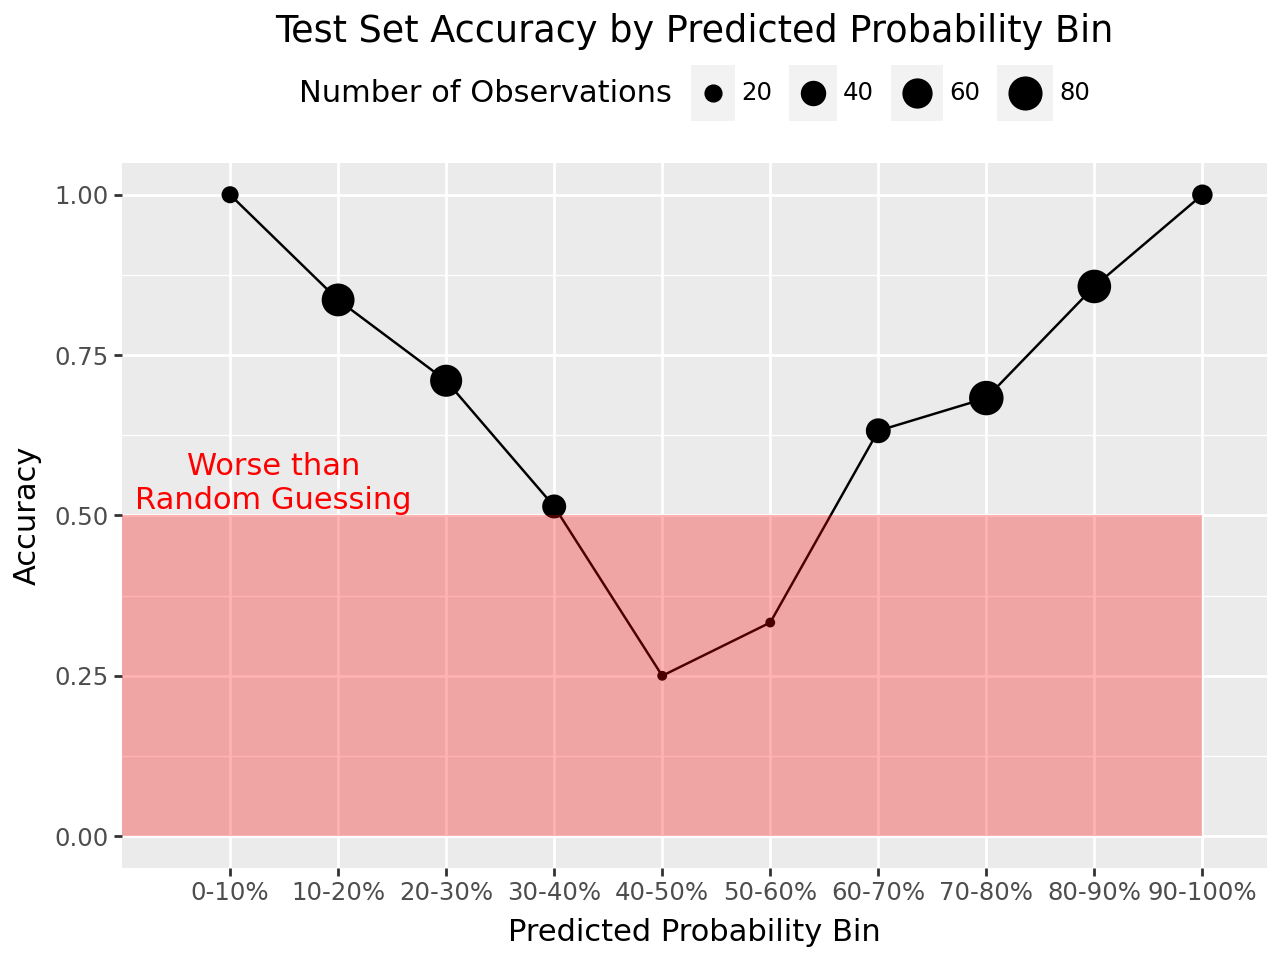

In [158]:
ggplot(data = temp) + geom_point(aes(x = "bin", y = "acc", size = "num")) + geom_line(
    aes(x = "bin", y = "acc", group = 1)) + xlab("Predicted Probability Bin") + ylab(
  "Accuracy") + labs(title = "Test Set Accuracy by Predicted Probability Bin"
  ) + ylim(0,1) + annotate("polygon", x = np.array(
    [0, 0, 10, 10]), y = np.array([.5, 0, 0, .5]), fill = "red", alpha = .3) + annotate(
    "text", x = 1.4, y = .55, label = "Worse than\nRandom Guessing", color = "red"
 ) + theme(legend_position="top") + guides(
size = guide_legend("Number of Observations") )

In [174]:
temp = df.groupby("bin")["correct"].sum().reset_index()
temp["num"] = df.groupby("bin")["correct"].count().reset_index()["correct"]
temp["acc"] = np.round(temp["correct"]/temp["num"], 3)
temp

,bin,correct,num,acc
0,0-10%,21,22,0.955
1,10-20%,31,39,0.795
2,20-30%,39,48,0.812
3,30-40%,43,56,0.768
4,40-50%,23,48,0.479
5,50-60%,35,55,0.636
6,60-70%,37,53,0.698
7,70-80%,39,48,0.812
8,80-90%,31,35,0.886
9,90-100%,35,37,0.946


In [110]:
polygon = pd.DataFrame()
polygon["x"] = np.array([0, 0, 1, 1])
polygon["y"] = np.array([.5, 0, 0, .5])

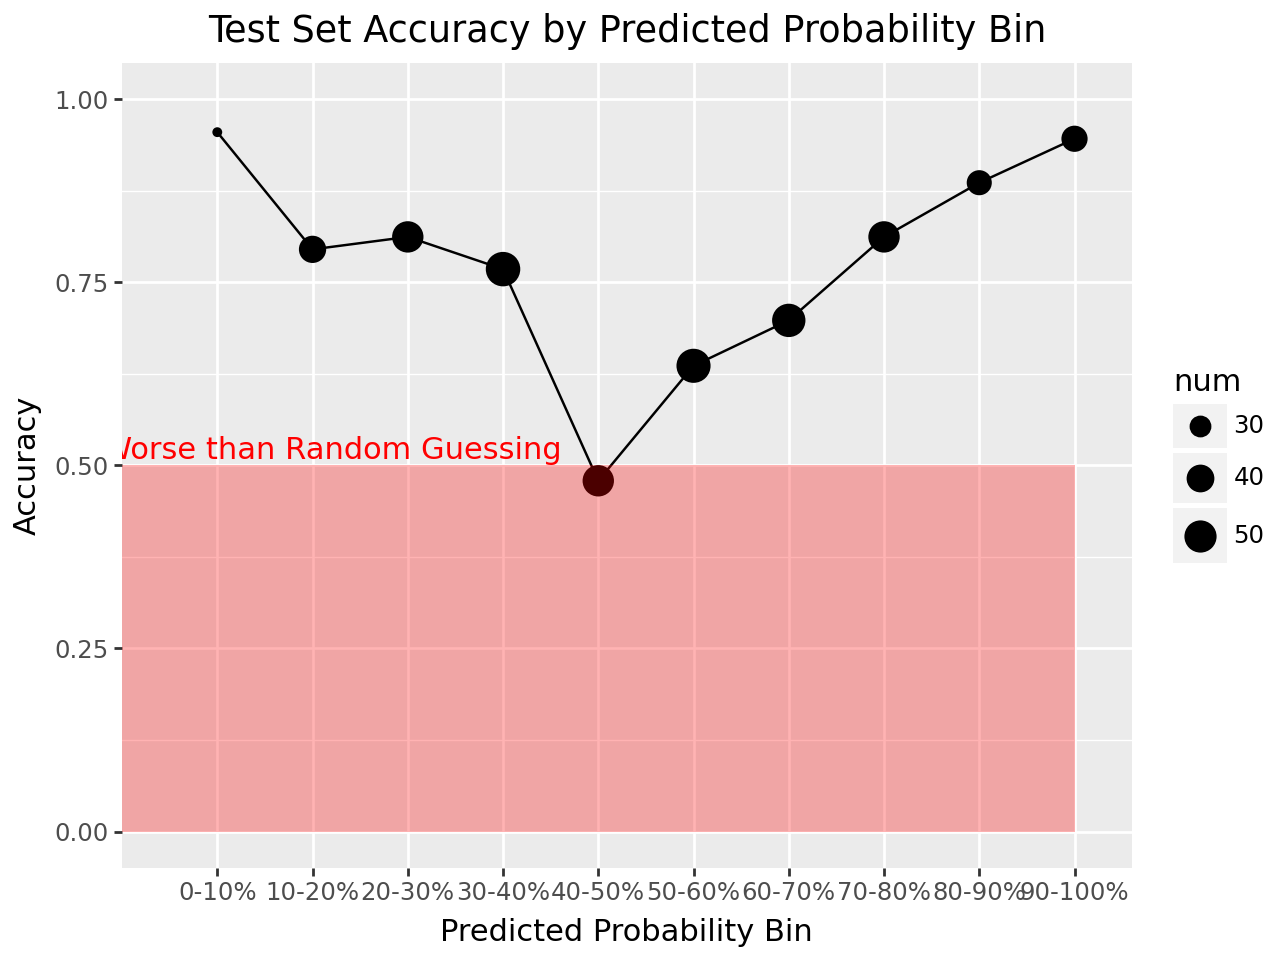

In [176]:
ggplot(data = temp) + geom_point(aes(x = "bin", y = "acc", size = "num")) + geom_line(
    aes(x = "bin", y = "acc", group = 1)) + xlab("Predicted Probability Bin") + ylab(
  "Accuracy") + labs(title = "Test Set Accuracy by Predicted Probability Bin"
  ) + ylim(0,1) + annotate("polygon", x = np.array(
    [0, 0, 10, 10]), y = np.array([.5, 0, 0, .5]), fill = "red", alpha = .3) + annotate(
    "text", x = 2.2, y = .52, label = "Worse than Random Guessing", color = "red")